In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
import warnings
warnings.filterwarnings("ignore")

In [16]:
df=pd.read_csv("/Users/lalitramanmishra/Data_Science/TimeSeries/daily_sales_french_bakery.csv",parse_dates=["ds"])

In [17]:
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [18]:
df=df.groupby('unique_id').filter(lambda x: len(x)>28)
df=df.drop(columns=["unit_price"])
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


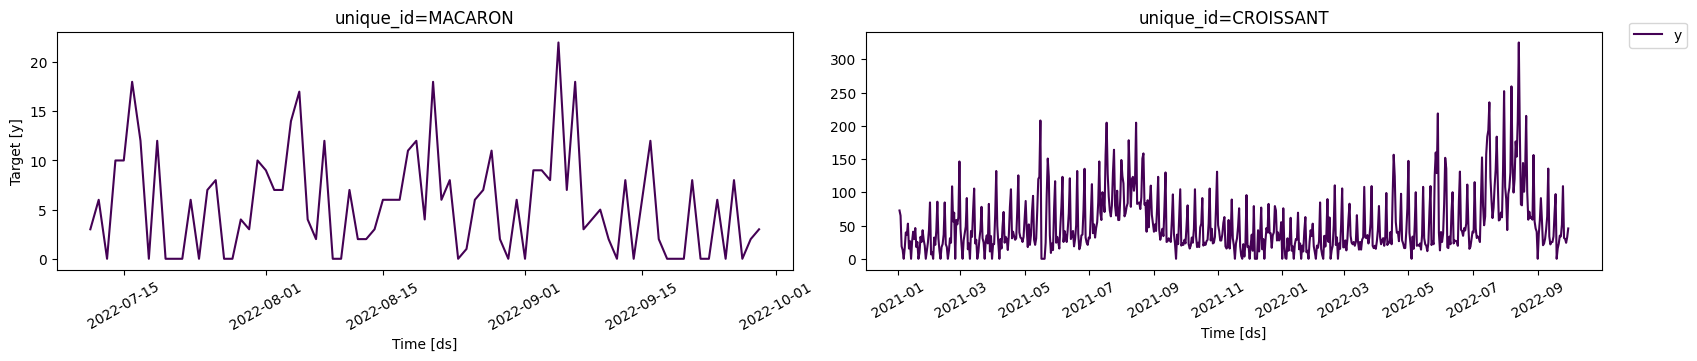

In [19]:
plot_series(df=df, ids=["MACARON","CROISSANT"],palette="viridis")

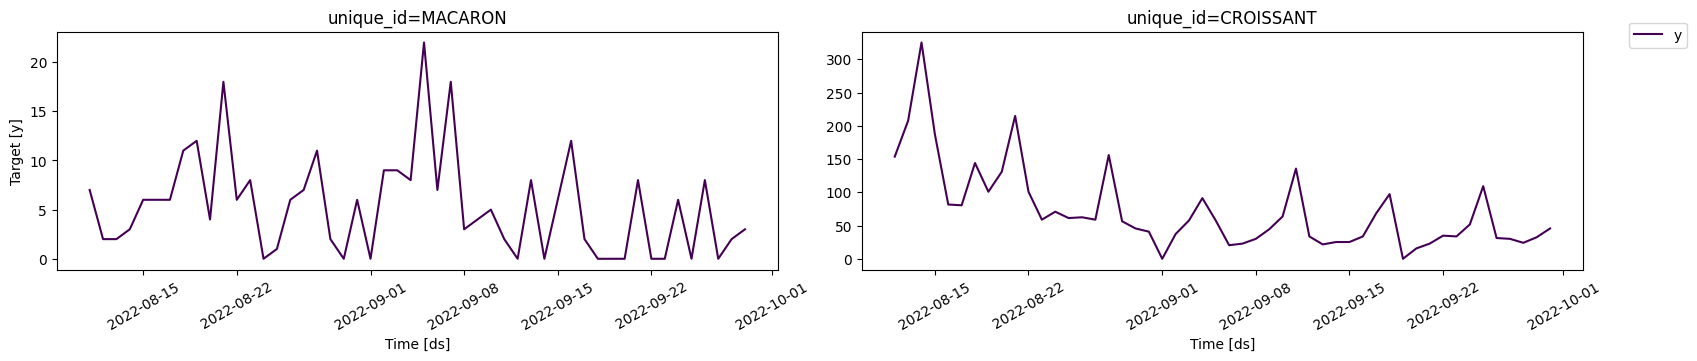

In [20]:
plot_series(df=df, ids=["MACARON","CROISSANT"],max_insample_length=50,palette="viridis")

In [24]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [29]:
horizon=7
models=[
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]
sf=StatsForecast(models=models,freq="D")
sf.fit(df=df)
pre=sf.predict(h=horizon)

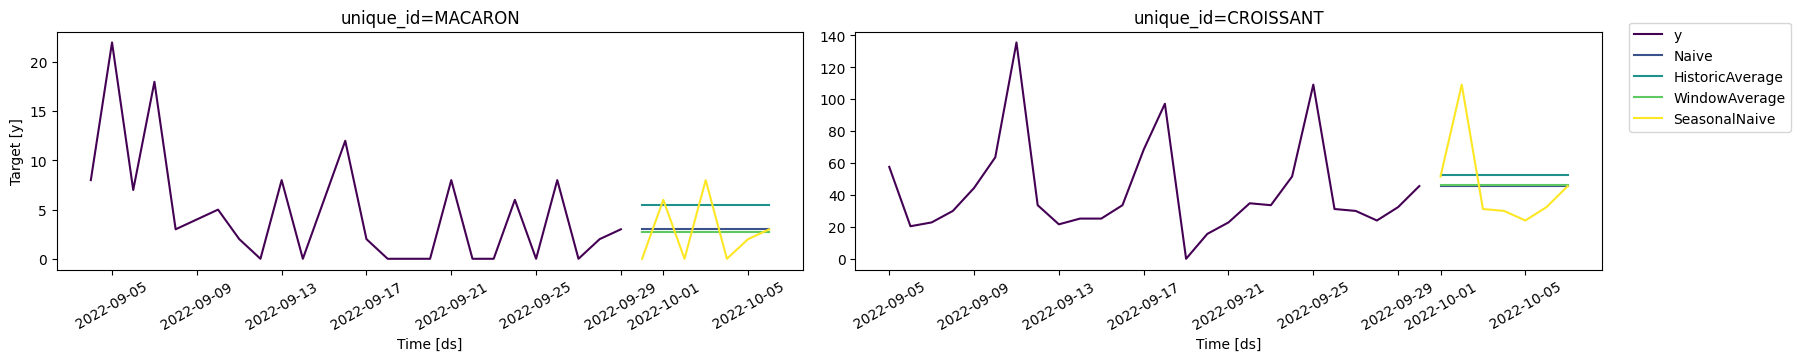

In [32]:
plot_series(df=df,
            forecasts_df=pre,
            ids=["MACARON","CROISSANT"],
            max_insample_length=26,
            palette="viridis")


In [34]:
test=df.groupby("unique_id").tail(7)
train=df.drop(test.index).reset_index(drop=True)
sf.fit(df=train)
ptre=sf.predict(h=horizon)
evaluate_df=pd.merge(test,ptre,"left",["ds","unique_id"])


In [39]:
evaluation=evaluate(
    evaluate_df,
    metrics=[mae]
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [41]:
evaluation.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


TypeError: 'value' must be an instance of str or bytes, not a numpy.float64

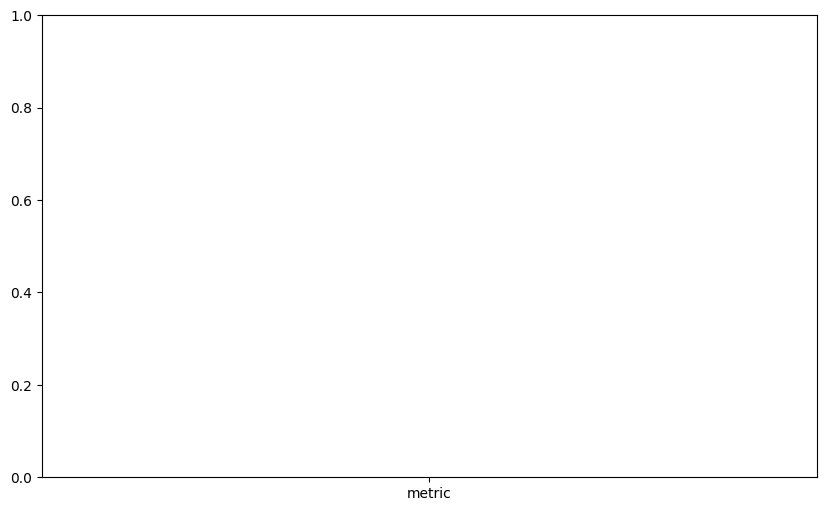

In [ ]:
methods=evaluation.columns[1:].to_list()
values=evaluation.iloc[0,1:].tolist()
plt.figure(figsize=(10,6))
bars=plt.bar(methods,values)
for bar,value in zip(bars,values):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height() + 0.05,
             f'{value:.3f}',ha='center',va='bottom',fontweight='bold')
    
plt.xlabel("Methods")
plt.ylabel("MAE")
plt.show()